GRGRATWGGSRRYKWGTTSCAGCGRATTGTAATACGACTCACTATAGGGCGAATTCGAGCTCGGTACCCGGGGWATCCTCTAGAGTCGACCTGCAGGCATGCAAGCTTGAGTATTCTATAGTGTCACCTAAATAGCTTGGCGTAATCATGGTCATAGCTGTTTCCTGTGTGAAATTGTTATCCGCTCACAATTCCACACAACATACGAGCCGGAAGCATAAAGTGTAAAGCCTGGGGTGCCTAATGAGTGAGCTAACTCACATTAATTGCGTTGCGCTCACTGCCCGCTTTCCAGTCGGGAAACCTGTCGTGCCAGCTGCATTAATGAATCGGCCAACGCGCGGGGAGAGGCGGTTTGCGTATTGGGCGCTCTTCCGCTTCCTCGCTCACTGACTCGCTGCGCTCGGTCGTTCGGCTGCGGCGAGCGGTATCAGCTCACTCAAAGGCGGTAATACGGTTATCCACAGAATCAGGGGATAACGCAGGAAAGAACATGTGAGCAAAAGGCCAGCAAAAGGCCAGGAACCGTAAAAAGGCCGCGTTGCTGGCGTTTTTCCATAGGCTCCGCCCCCCTGACGAGCATCACAAAAATCGACGCTCAAGTCAGAGGTGGCGAAACCCGACAGGACTATAAAGATACCAGGCGTTTCCCCCTGGAAGCTCCCTCGTGCGCTCTCCTGTTCCGACCTGCCGCTTACCGGATACTGTCCGCCTTTCTCCCTTCGGAAGCGTGGCCTTTTCTCATAGCTCACGCTGTAGGTATCTCAGTTCGG
Считано: 773 оснований
Комментарии: 


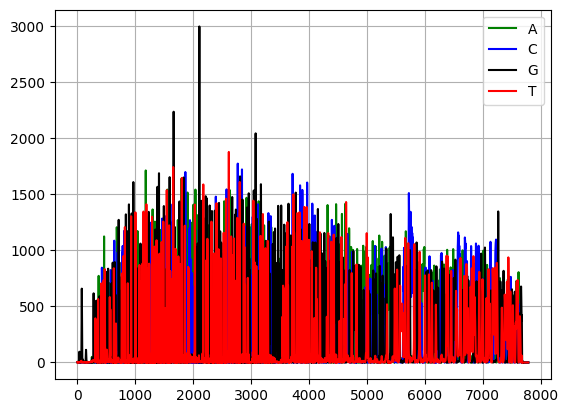

In [32]:
import struct

def swap_endian():
    import sys
    return '>' if sys.byteorder == 'little' else '<'
import pandas as pd


    

def scfread(filename):
    """
    Читает SCF-файл (Standard Chromatogram Format) и извлекает сигналы трассировки, вероятности оснований,
    индексы пиков, последовательность нуклеотидов и комментарии.

    Параметры:
    ----------
    filename : str
        Полный путь к SCF-файлу.

    Возвращает:
    -----------
    tuple :
        - df_traces (pd.DataFrame): DataFrame с трассировками каналов 'A', 'C', 'G', 'T'
                                     после двойной интеграции.
        - A (list[int]): Трассировка сигнала аденина после двойной интеграции.
        - C (list[int]): Трассировка сигнала цитозина после двойной интеграции.
        - G (list[int]): Трассировка сигнала гуанина после двойной интеграции.
        - T (list[int]): Трассировка сигнала тимина после двойной интеграции.
        - prob_A (list[int]): Вероятности для A (0–255).
        - prob_C (list[int]): Вероятности для C (0–255).
        - prob_G (list[int]): Вероятности для G (0–255).
        - prob_T (list[int]): Вероятности для T (0–255).
        - comments (str): Комментарии из SCF-файла.
        - peak_index (list[int]): Индексы пиков, соответствующих положениям баз.
        - base (str): Последовательность нуклеотидов (строка из символов A, C, G, T).

    Исключения:
    -----------
    ValueError:
        Если размер выборки (sample size) не равен 1 или 2.

    Пример:
    -------
    >>> df, A, C, G, T, pA, pC, pG, pT, comments, peaks, seq = scfread("sample.scf")
    >>> df.head()
        A     C     G     T
    0  12    14    10    13
    1  25    29    21    28
    ...
    """
    endian = swap_endian()

    with open(filename, 'rb') as f:
        header = f.read(128)
        (
        magic,
        num_samples,
        samples_offset,
        num_bases,
        left_clip,
        right_clip,
        bases_offset,
        comments_size,
        comments_offset,
        version_bytes,     # 4s
        sample_size,       # uint32 ← теперь корректно
        codeset,
        private_size,
        private_offset,
         spare
        ) = struct.unpack(endian + '4s8I4s5I', header[:60])


       
        version_bytes = header[36:40]  # гарантированно 4 байта для версии
        version = version_bytes.decode('ascii').strip('\x00')


        # Определение типа выборки
        if sample_size == 1:
            sample_type = 'b'  # signed char (int8)
        elif sample_size == 2:
            sample_type = 'h'  # signed short (int16)
        else:
            raise ValueError(f"Unsupported sample size: {sample_size}")

        # Чтение сигналов трассировки (A, C, G, T)
        f.seek(samples_offset)
        A = list(struct.unpack(endian + sample_type * num_samples, f.read(sample_size * num_samples)))
        C = list(struct.unpack(endian + sample_type * num_samples, f.read(sample_size * num_samples)))
        G = list(struct.unpack(endian + sample_type * num_samples, f.read(sample_size * num_samples)))
        T = list(struct.unpack(endian + sample_type * num_samples, f.read(sample_size * num_samples)))

        # Двойное интегрирование (по аналогии с MATLAB)
        def double_integrate(trace):
            integrated = []
            acc = 0
            for v in trace:
                acc += v
                integrated.append(acc)
            result = []
            acc2 = 0
            for v in integrated:
                acc2 += v
                result.append(acc2)
            return result

        A = double_integrate(A)
        C = double_integrate(C)
        G = double_integrate(G)
        T = double_integrate(T)

        # Чтение информации о базах
        f.seek(bases_offset)
        peak_index = list(struct.unpack(endian + f'{num_bases}I', f.read(4 * num_bases)))
        prob_A = list(struct.unpack(endian + f'{num_bases}B', f.read(num_bases)))
        prob_C = list(struct.unpack(endian + f'{num_bases}B', f.read(num_bases)))
        prob_G = list(struct.unpack(endian + f'{num_bases}B', f.read(num_bases)))
        prob_T = list(struct.unpack(endian + f'{num_bases}B', f.read(num_bases)))
        base = f.read(num_bases).decode('ascii')

        # Пропустить "spare" данные (3*num_bases байт)
        f.seek(3 * num_bases, 1)

        # Чтение комментариев
        f.seek(comments_offset)
        comments = f.read(comments_size).decode('ascii').strip()

    df_traces = pd.DataFrame({'A': A,'C': C,'G': G, 'T': T})


    return df_traces,A, C, G, T, prob_A, prob_C, prob_G, prob_T, comments, peak_index, base

color_map = {
    'G': 'black',
    'A': 'green',
    'T': 'red',
    'C': 'blue'
}

import matplotlib.pyplot as plt
def main():
    path = "C:/Users/evgen/Documents/GitHub/dnacsv/files/обработанные SCF в Mutation Surveyor/обработанные SCF в Mutation Surveyor/2_pGEM_G2_PDMA6_36.ab1.scf"
    df_traces,A, C, G, T, pA, pC, pG, pT, comments, peaks, base = scfread(path)

    print(base)
    # print(pC)
    # print(peaks)
    print("Считано:", len(base), "оснований")
    print("Комментарии:", comments[:100])  # Показать первые 100 символов
    colors = [color_map[col] for col in df_traces.columns]
    df_traces.plot(color=colors)
    plt.grid(True)

if __name__ == "__main__":
    main()





